# Notebook Demo: Bande de frequence, Décodage ML: Go/NoGo.

Notebook pour transformer les enregistrements Go/NoGo prétraités en un pipeline d'apprentissage supervisé accessible. Le contenu reprend la logique pédagogique des notebooks ,  et  et résume le cahier  en étapes guidées.


## Contexte et objectifs

- Repartir des fichiers FIF propres () et vérifier rapidement la qualité des signaux.
- Extraire descripteurs simples (fenêtres ERP + bandes fréquentielles) par essai pour alimenter des classifieurs linéaires.
- Documenter chaque bloc de code pour les étudiantes et étudiants en psychologie peu familiers avec Python.


## 0. Préparation et configuration

Chaque bloc ci-dessous doit être exécuté une fois au début du notebook : imports, paramètres, puis fonctions utilitaires déjà rédigées pour vous.


### Bloc Type 1 — Imports et options globales


In [ ]:

import warnings
from pathlib import Path
import json
import math
from typing import Dict, List, Optional, Sequence, Tuple

import mne
from mne import Epochs
import numpy as np
import pandas as pd
from IPython.display import display
from mne.preprocessing import Xdawn
from mne.time_frequency import tfr_morlet
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, cross_val_score, permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

import traceback

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:.3f}".format


### Bloc Type 1 — Définir les chemins et paramètres Go/NoGo

Adaptez uniquement ,  ou les fenêtres temporelles si vos fichiers sont ailleurs ou si vous souhaitez explorer d'autres composantes.


In [ ]:

DATA_DIR = Path("data/gonogo/bids")
FILE_GLOB = "derivatives/neurotheque-preproc/**/sub-*_processed.fif"
RESULTS_DIR = Path("derivatives")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EVENT_ID = {"Go": 4, "NoGo": 5}
PREFER_METADATA_CONDITION = True
BASELINE = (-0.2, 0.0)
EPOCHING_TMIN = -0.2
EPOCHING_TMAX = 0.8

CHANNEL_CLUSTERS = {
    "midline_fc": ["Fz", "Cz"],
    "parietal": ["Pz", "P3", "P4"],
    "motor_left": ["C3"],
    "motor_right": ["C4"],
}

ERP_MEAN_WINDOWS = [
    {"name": "N2_mean_200_350", "cluster": "midline_fc", "tmin": 0.200, "tmax": 0.350},
    {"name": "P3_mean_300_600_midline_fc", "cluster": "midline_fc", "tmin": 0.300, "tmax": 0.600},
    {"name": "P3_mean_300_600_parietal", "cluster": "parietal", "tmin": 0.300, "tmax": 0.600},
]

ERP_PEAK_WINDOWS = [
    {"name": "N2_peak_200_350", "cluster": "midline_fc", "tmin": 0.200, "tmax": 0.350, "mode": "min"},
    {"name": "P3_peak_300_600", "cluster": "parietal", "tmin": 0.300, "tmax": 0.600, "mode": "max"},
]

TFR_CONFIG = {
    "enabled": True,
    "baseline": (-0.2, 0.0),
    "mode": "logratio",
    "n_jobs": 1,
    "method": "morlet",
    "safe_epoch_fraction": 0.50,
    "min_cycles": 2.0,
    "max_cycles": 7.0,
    "hilbert_fallback": True,
    "specs": [
        {"name": "theta_midline_fc", "cluster": "midline_fc", "freq_range": (5.0, 7.0), "n_freqs": 3, "tmin": 0.200, "tmax": 0.500},
        {"name": "mu_left", "cluster": "motor_left", "freq_range": (8.0, 13.0), "n_freqs": 5, "tmin": 0.050, "tmax": 0.300},
        {"name": "mu_right", "cluster": "motor_right", "freq_range": (8.0, 13.0), "n_freqs": 5, "tmin": 0.050, "tmax": 0.300},
        {"name": "beta_left", "cluster": "motor_left", "freq_range": (13.0, 25.0), "n_freqs": 7, "tmin": 0.050, "tmax": 0.300},
        {"name": "beta_right", "cluster": "motor_right", "freq_range": (13.0, 25.0), "n_freqs": 7, "tmin": 0.050, "tmax": 0.300},
    ],
}

QC_CHANNELS = ["Fz", "Cz", "Pz"]

RANDOM_SEED = 42
WITHIN_SUBJECT_SPLITS = 5

CLASSIFIER_CONFIG = {
    "LogisticRegression": {"type": "logreg", "params": {"class_weight": "balanced", "max_iter": 500, "solver": "lbfgs"}},
    "LinearSVM": {"type": "linear_svm", "params": {"class_weight": "balanced", "max_iter": 5000}},
    "LDA": {"type": "lda", "params": {}},
}

FEATURES_OUT = RESULTS_DIR / "features_gonogo_ml.csv"
RESULTS_SUMMARY_OUT = RESULTS_DIR / "results_gonogo_ml.json"

QC_PLOTS = True
XDAWN_ENABLED = False
RUN_PERMUTATION_TEST = False
PERMUTATION_MODEL = "LogisticRegression"
PERMUTATION_N = 200

MNE_LOG_LEVEL = "WARNING"
PRINT_PROGRESS = True

QC_REFERENCE_EPOCHS = None
QC_REFERENCE_LABELS = None
ALL_EPOCH_FILES: List[Path] = []

mne.set_log_level(MNE_LOG_LEVEL)
print(f"Chemin de travail : {DATA_DIR.resolve()}")


### Bloc Type 1 — Toutes les fonctions utilitaires (à exécuter une fois)

⚠️ **IMPORTANT POUR LES ÉTUDIANTS**: 
Cette cellule contient TOUTES les fonctions nécessaires pour le notebook.
Vous n'avez PAS besoin de comprendre chaque ligne de code!

**Ce qu'il faut savoir:**
- Ces fonctions sont des "outils" que nous utiliserons plus tard
- Pensez-y comme des recettes de cuisine que nous appliquerons ensuite
- **Exécutez simplement cette cellule UNE FOIS au début**
- Les fonctions sont organisées en 3 groupes:
  1. **Chargement des données** (lignes 1-100): Pour ouvrir les fichiers EEG
  2. **Extraction de features** (lignes 101-200): Pour calculer les caractéristiques
  3. **Machine Learning** (lignes 201-fin): Pour évaluer les modèles

💡 **Conseil**: Ne vous inquiétez pas du code ici. Concentrez-vous sur les sections suivantes où nous UTILISONS ces outils!


In [35]:
# Fonction 1 : Trouver les fichiers FIF traités
def find_epoch_files(data_dir: Path, pattern: str) -> List[Path]:
    """
    Cherche tous les fichiers .fif correspondant au pattern dans data_dir.
    Retourne une liste triée de chemins vers ces fichiers.
    """
    files = sorted(data_dir.glob(pattern))
    if not files:
        print(f"[warn] Aucun fichier FIF trouvé avec le pattern '{pattern}' dans {data_dir}.")
    return files


# Fonction 2 : Extraire l'identifiant du sujet depuis le nom de fichier
def parse_subject_id(file_path: Path) -> str:
    """
    Cherche 'sub-XX' dans le chemin du fichier.
    Exemple: si le fichier est 'sub-01/session/data.fif', retourne 'sub-01'
    """
    for part in file_path.parts:
        if part.lower().startswith("sub-"):
            return part
    return file_path.parent.name


# Fonction 3 : Normaliser les labels de condition (Go/NoGo)
def normalize_condition_label(value: object) -> str:
    """
    Convertit différentes variantes de labels (go, Go, GO, nogo, etc.)
    en deux catégories standard: "Go" ou "NoGo"
    """
    if value is None:
        return ""
    token = str(value).strip().lower()
    token = token.replace("-", "").replace("_", "").replace(" ", "")
    if token.startswith("nogo") or "withhold" in token:
        return "NoGo"
    if token.startswith("go") and "nogo" not in token:
        return "Go"
    return ""


def extract_condition_labels(
    epochs: Epochs, event_id: Dict[str, int], prefer_metadata: bool = True
) -> np.ndarray:
    """Return per-epoch labels, preferring metadata when available."""
    labels: List[str] = []
    if prefer_metadata and epochs.metadata is not None and "condition" in epochs.metadata.columns:
        labels = [normalize_condition_label(value) for value in epochs.metadata["condition"]]
    else:
        inv_map = {code: name for name, code in event_id.items()}
        for code in epochs.events[:, 2]:
            label = inv_map.get(int(code), "")
            labels.append(normalize_condition_label(label))
    return np.array(labels, dtype=object)


def filter_go_nogo_epochs(epochs: Epochs, labels: np.ndarray) -> Tuple[Epochs, np.ndarray]:
    """Keep only Go/NoGo trials and propagate the condition column."""
    keep_mask = np.isin(labels, ("Go", "NoGo"))
    if not keep_mask.any():
        raise ValueError("No Go/NoGo trials remain after filtering.")
    filtered = epochs[keep_mask]
    filtered_labels = labels[keep_mask]
    if epochs.metadata is not None:
        metadata = epochs.metadata.iloc[np.flatnonzero(keep_mask)].copy()
        metadata["condition"] = filtered_labels
    else:
        metadata = pd.DataFrame({"condition": filtered_labels})
    filtered.metadata = metadata.reset_index(drop=True)
    filtered.event_id = {"Go": EVENT_ID["Go"], "NoGo": EVENT_ID["NoGo"]}
    return filtered, filtered_labels


def ensure_montage(epochs: Epochs) -> None:
    """Attach the standard_1020 montage if none is present."""
    if epochs.get_montage() is not None:
        return
    try:
        epochs.set_montage("standard_1020", match_case=False, on_missing="ignore")
    except RuntimeError as exc:  # noqa: BLE001
        print(f"[warn] Could not set montage: {exc}")


def prepare_epochs(file_path: Path) -> Tuple[Epochs, np.ndarray, str]:
    """Load continuous data, create epochs, baseline-correct, and filter to Go/NoGo."""
    # Load continuous preprocessed data
    raw = mne.io.read_raw_fif(file_path, preload=True, verbose="ERROR")
    ensure_montage_raw(raw)

    # Find events in the continuous data (Trigger channel contains event codes)
    events = mne.find_events(raw, stim_channel='Trigger', shortest_event=1, verbose="ERROR")

    # Create epochs from continuous data
    epochs = mne.Epochs(
        raw, 
        events, 
        event_id=EVENT_ID, 
        tmin=EPOCHING_TMIN, 
        tmax=EPOCHING_TMAX,
        baseline=BASELINE,
        preload=True,
        verbose="ERROR"
    )

    labels = extract_condition_labels(epochs, EVENT_ID, PREFER_METADATA_CONDITION)
    epochs, labels = filter_go_nogo_epochs(epochs, labels)
    subject_id = parse_subject_id(file_path)
    return epochs, labels, subject_id


def ensure_montage_raw(raw: mne.io.Raw) -> None:
    """Attach the standard_1020 montage to raw data if none is present."""
    if raw.get_montage() is not None:
        return
    try:
        raw.set_montage("standard_1020", match_case=False, on_missing="ignore")
    except RuntimeError as exc:  # noqa: BLE001
        print(f"[warn] Could not set montage: {exc}")


def get_cluster_channels(epochs: Epochs, cluster: Sequence[str]) -> List[str]:
    """Return available channels for ``cluster``; fail if none remain."""
    picks = [ch for ch in cluster if ch in epochs.ch_names]
    if not picks:
        raise ValueError(f"No available channels for cluster {cluster}.")
    return picks


def _window_mask(times: np.ndarray, tmin: float, tmax: float) -> np.ndarray:
    return (times >= tmin) & (times <= tmax)


def mean_amplitude(epochs: Epochs, picks: Sequence[str], tmin: float, tmax: float) -> np.ndarray:
    mask = _window_mask(epochs.times, tmin, tmax)
    if not mask.any():
        return np.full(len(epochs), np.nan)
    data = epochs.get_data(picks=picks)[:, :, mask]
    return data.mean(axis=(1, 2))


def peak_value_and_latency(
    epochs: Epochs, picks: Sequence[str], tmin: float, tmax: float, mode: str
) -> Tuple[np.ndarray, np.ndarray]:
    mask = _window_mask(epochs.times, tmin, tmax)
    if not mask.any():
        nan_array = np.full(len(epochs), np.nan)
        return nan_array, nan_array.copy()
    data = epochs.get_data(picks=picks)[:, :, mask].mean(axis=1)
    arg_func = np.argmin if mode == "min" else np.argmax
    peak_idx = arg_func(data, axis=1)
    times = epochs.times[mask]
    values = data[np.arange(len(epochs)), peak_idx]
    latencies = times[peak_idx]
    return values, latencies


def _safe_cycles_per_freq(
    freqs: np.ndarray,
    epoch_len: float,
    min_cycles: float,
    max_cycles: float,
    safe_fraction: float
) -> np.ndarray:
    """
    Compute per-frequency n_cycles so each Morlet's temporal support
    (approx ~ n_cycles / f) stays <= safe_fraction * epoch_len.
    """
    # Max cycles allowed so that (n_cycles / f) <= safe_fraction * epoch_len
    max_allowed = safe_fraction * epoch_len * freqs
    n_cycles = np.minimum(max_cycles, np.maximum(min_cycles, max_allowed))
    return n_cycles


def compute_band_envelope_hilbert(
    epochs: Epochs,
    picks: Sequence[str],
    l_freq: float,
    h_freq: float,
    tmin: float,
    tmax: float,
    n_jobs: Optional[int] = None
) -> np.ndarray:
    """
    Band-pass + Hilbert envelope per epoch/channel; mean over ch × time.
    Robust for short epochs and very low frequencies (e.g., 4 Hz).
    """
    if not picks:
        return np.full(len(epochs), np.nan)

    ep = epochs.copy().filter(
        l_freq=l_freq, h_freq=h_freq, picks=picks,
        method="fir", phase="zero-double", fir_window="hamming",
        n_jobs=n_jobs, verbose="ERROR"
    )
    ep.apply_hilbert(envelope=True, picks=picks, verbose="ERROR")
    data = ep.get_data(picks=picks)  # (n_trials, n_ch, n_times)
    mask = _window_mask(ep.times, tmin, tmax)
    if not mask.any():
        return np.full(len(epochs), np.nan)
    return data[:, :, mask].mean(axis=(1, 2))


def compute_tfr_band_power(
    epochs: Epochs,
    picks: Sequence[str],
    freq_range: Tuple[float, float],
    n_freqs: int,
    tmin: float,
    tmax: float,
    baseline: Optional[Tuple[float, float]],
    mode: str,
    n_jobs: Optional[int],
    # New optional controls (pulled from TFR_CONFIG):
    method: Optional[str] = None,
    min_cycles: Optional[float] = None,
    max_cycles: Optional[float] = None,
    safe_epoch_fraction: Optional[float] = None,
    hilbert_fallback: bool = True,
) -> np.ndarray:
    if not picks:
        return np.full(len(epochs), np.nan)

    method = method or "morlet"
    epoch_len = float(epochs.times[-1] - epochs.times[0])

    fmin, fmax = freq_range
    freqs = np.linspace(fmin, fmax, n_freqs)

    if method.lower() == "hilbert":
        return compute_band_envelope_hilbert(
            epochs, picks, fmin, fmax, tmin, tmax, n_jobs=n_jobs
        )

    # Morlet path with safety constraints
    min_cycles = 2.0 if min_cycles is None else float(min_cycles)
    max_cycles = 7.0 if max_cycles is None else float(max_cycles)
    safe_epoch_fraction = 0.50 if safe_epoch_fraction is None else float(safe_epoch_fraction)

    # cycles per freq so that (n_cycles / f) <= safe_fraction * epoch_len
    n_cycles = _safe_cycles_per_freq(freqs, epoch_len, min_cycles, max_cycles, safe_epoch_fraction)

    # If still unsafe for very low f, use Hilbert fallback
    # (e.g., epochs are very short or baseline eats too much)
    longest_support = np.max(n_cycles / freqs)  # seconds
    if hilbert_fallback and (longest_support > safe_epoch_fraction * epoch_len + 1e-9):
        return compute_band_envelope_hilbert(
            epochs, picks, fmin, fmax, tmin, tmax, n_jobs=n_jobs
        )

    power = tfr_morlet(
        epochs, freqs=freqs, n_cycles=n_cycles, picks=picks,
        average=False, return_itc=False, use_fft=True,
        n_jobs=n_jobs, verbose="ERROR"
    )
    if baseline is not None:
        power.apply_baseline(baseline=baseline, mode=mode)
    mask = _window_mask(power.times, tmin, tmax)
    if not mask.any():
        return np.full(len(epochs), np.nan)
    data = power.data[:, :, :, mask]  # (n_trials, n_ch, n_freq, n_time)
    return data.mean(axis=(1, 2, 3))


def build_feature_table(epochs: Epochs, labels: np.ndarray, subject_id: str, source_path: Path) -> pd.DataFrame:
    """Assemble single-trial ERP and TFR features for one recording."""
    picks_cache: Dict[str, List[str]] = {}

    def cluster_picks(name: str) -> List[str]:
        if name not in CHANNEL_CLUSTERS:
            raise KeyError(f"Unknown cluster '{name}'.")
        if name not in picks_cache:
            picks_cache[name] = get_cluster_channels(epochs, CHANNEL_CLUSTERS[name])
        return picks_cache[name]

    feature_map: Dict[str, np.ndarray] = {}
    for spec in ERP_MEAN_WINDOWS:
        picks = cluster_picks(spec["cluster"])
        feature_map[spec["name"]] = mean_amplitude(epochs, picks, spec["tmin"], spec["tmax"])
    for spec in ERP_PEAK_WINDOWS:
        picks = cluster_picks(spec["cluster"])
        values, latencies = peak_value_and_latency(epochs, picks, spec["tmin"], spec["tmax"], spec["mode"])
        feature_map[f"{spec['name']}_value"] = values
        feature_map[f"{spec['name']}_latency"] = latencies
    if TFR_CONFIG.get("enabled", False):
        for spec in TFR_CONFIG.get("specs", []):
            picks = cluster_picks(spec["cluster"])
            feature_map[spec["name"]] = compute_tfr_band_power(
                epochs=epochs,
                picks=picks,
                freq_range=spec["freq_range"],
                n_freqs=spec["n_freqs"],
                tmin=spec["tmin"],
                tmax=spec["tmax"],
                baseline=TFR_CONFIG.get("baseline"),
                mode=TFR_CONFIG.get("mode", "logratio"),
                n_jobs=TFR_CONFIG.get("n_jobs"),
                method=spec.get("method", TFR_CONFIG.get("method", "morlet")),
                min_cycles=TFR_CONFIG.get("min_cycles", 2.0),
                max_cycles=TFR_CONFIG.get("max_cycles", 7.0),
                safe_epoch_fraction=TFR_CONFIG.get("safe_epoch_fraction", 0.50),
                hilbert_fallback=TFR_CONFIG.get("hilbert_fallback", True),
            )

    base_info = {
        "subject_id": subject_id,
        "source_file": source_path.name,
        "source_path": str(source_path),
        "trial_index": np.arange(len(labels)),
        "condition": labels,
    }
    return pd.DataFrame({**base_info, **feature_map})


def instantiate_classifier(name: str, spec: Dict[str, object]):
    """Build a StandardScaler + classifier pipeline from the config entry."""
    kind = spec.get("type")
    params = dict(spec.get("params", {}))
    if kind == "logreg":
        params.setdefault("random_state", RANDOM_SEED)
        estimator = LogisticRegression(**params)
    elif kind == "linear_svm":
        params.setdefault("random_state", RANDOM_SEED)
        estimator = LinearSVC(**params)
    elif kind == "lda":
        estimator = LinearDiscriminantAnalysis(**params)
    else:
        raise ValueError(f"Unknown classifier type '{kind}'.")
    return make_pipeline(StandardScaler(), estimator)


def evaluate_within_subject(
    X: np.ndarray,
    y: np.ndarray,
    subjects: np.ndarray,
    classifier_config: Dict[str, Dict[str, object]],
    n_splits: int,
) -> Dict[str, Dict[str, object]]:
    """Compute stratified K-fold balanced accuracy per subject for each model."""
    results: Dict[str, Dict[str, object]] = {}
    unique_subjects = np.unique(subjects)
    for name, spec in classifier_config.items():
        subject_scores: Dict[str, float] = {}
        for subject in unique_subjects:
            mask = subjects == subject
            if mask.sum() < 2:
                continue
            y_sub = y[mask]
            if np.unique(y_sub).size < 2:
                continue
            class_counts = np.bincount(y_sub)
            class_counts = class_counts[class_counts > 0]
            if class_counts.size == 0:
                continue
            splits = min(n_splits, int(class_counts.min()))
            if splits < 2:
                continue
            cv = StratifiedKFold(n_splits=splits, shuffle=True, random_state=RANDOM_SEED)
            pipeline = instantiate_classifier(name, spec)
            scores = cross_val_score(pipeline, X[mask], y_sub, cv=cv, scoring="balanced_accuracy")
            subject_scores[subject] = float(np.mean(scores))
        results[name] = {
            "per_subject": subject_scores,
            "mean_balanced_accuracy": float(np.mean(list(subject_scores.values())))
            if subject_scores
            else float("nan"),
        }
    return results


def _continuous_scores(model, X_test: np.ndarray) -> Optional[np.ndarray]:
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
    elif hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test)[:, 1]
    else:
        return None
    if isinstance(scores, (list, tuple)):
        scores = np.asarray(scores)
    if scores.ndim > 1:
        scores = scores[:, 0]
    return scores


def safe_roc_auc(y_true: np.ndarray, scores: Optional[np.ndarray]) -> float:
    if scores is None or np.unique(y_true).size < 2:
        return float("nan")
    try:
        return float(roc_auc_score(y_true, scores))
    except ValueError:
        return float("nan")


def evaluate_loso(
    X: np.ndarray,
    y: np.ndarray,
    subjects: np.ndarray,
    classifier_config: Dict[str, Dict[str, object]],
) -> Dict[str, Dict[str, object]]:
    """Perform leave-one-subject-out evaluation for each classifier."""
    results: Dict[str, Dict[str, object]] = {}
    logo = LeaveOneGroupOut()
    for name, spec in classifier_config.items():
        folds = []
        for train_idx, test_idx in logo.split(X, y, groups=subjects):
            if np.unique(y[train_idx]).size < 2 or np.unique(y[test_idx]).size < 2:
                continue
            pipeline = instantiate_classifier(name, spec)
            pipeline.fit(X[train_idx], y[train_idx])
            y_pred = pipeline.predict(X[test_idx])
            y_score = _continuous_scores(pipeline, X[test_idx])
            folds.append(
                {
                    "held_out_subject": str(subjects[test_idx][0]),
                    "balanced_accuracy": float(balanced_accuracy_score(y[test_idx], y_pred)),
                    "f1": float(f1_score(y[test_idx], y_pred)),
                    "roc_auc": safe_roc_auc(y[test_idx], y_score),
                    "n_test": int(len(test_idx)),
                }
            )
        if folds:
            roc_values = [fold["roc_auc"] for fold in folds if not math.isnan(fold["roc_auc"])]
            results[name] = {
                "folds": folds,
                "mean_balanced_accuracy": float(np.mean([fold["balanced_accuracy"] for fold in folds])),
                "mean_f1": float(np.mean([fold["f1"] for fold in folds])),
                "mean_roc_auc": float(np.mean(roc_values)) if roc_values else float("nan"),
            }
        else:
            results[name] = {
                "folds": [],
                "mean_balanced_accuracy": float("nan"),
                "mean_f1": float("nan"),
                "mean_roc_auc": float("nan"),
            }
    return results


📚 **Note pédagogique**: Les fonctions de chargement ont déjà été définies dans la cellule précédente. Vous pouvez maintenant les utiliser!


In [21]:

# ============================================================================
# AIDE : FONCTIONS PRINCIPALES DÉFINIES CI-DESSUS
# ============================================================================
# Si vous voulez comprendre en détail ce que font les fonctions,
# voici les plus importantes et leur rôle:
#
# 1. prepare_epochs() - Charge un fichier EEG et crée les époques
#    → C'est la fonction la plus utilisée dans le notebook
#
# 2. build_feature_table() - Extrait toutes les caractéristiques ERP/TFR
#    → Utilisée dans la Section 3 pour créer le grand tableau
#
# 3. evaluate_within_subject() - Évalue les modèles intra-sujet
#    → Utilisée dans la Section 5 pour tester sur chaque participant
#
# 4. evaluate_loso() - Évalue avec leave-one-subject-out
#    → Utilisée dans la Section 5 pour la vraie généralisation
#
# Les autres fonctions sont des "helpers" (aides) utilisées par ces 4 principales.
# ============================================================================

# Fonction 4 : Extraire les labels de condition depuis les époques (DÉJÀ DÉFINIE)
def extract_condition_labels(
    epochs: Epochs, event_id: Dict[str, int], prefer_metadata: bool = True
) -> np.ndarray:
    """
    Extrait les labels Go/NoGo pour chaque époque.
    Utilise d'abord les métadonnées si disponibles, sinon les event_id.
    """
    labels: List[str] = []
    if prefer_metadata and epochs.metadata is not None and "condition" in epochs.metadata.columns:
        labels = [normalize_condition_label(value) for value in epochs.metadata["condition"]]
    else:
        inv_map = {code: name for name, code in event_id.items()}
        for code in epochs.events[:, 2]:
            label = inv_map.get(int(code), "")
            labels.append(normalize_condition_label(label))
    return np.array(labels, dtype=object)


# Fonction 5 : Filtrer pour ne garder que les essais Go et NoGo
def filter_go_nogo_epochs(epochs: Epochs, labels: np.ndarray) -> Tuple[Epochs, np.ndarray]:
    """
    Ne garde que les essais étiquetés "Go" ou "NoGo".
    Rejette les autres types d'événements s'il y en a.
    """
    keep_mask = np.isin(labels, ("Go", "NoGo"))
    if not keep_mask.any():
        raise ValueError("Aucun essai Go/NoGo trouvé après filtrage.")
    filtered = epochs[keep_mask]
    filtered_labels = labels[keep_mask]
    if epochs.metadata is not None:
        metadata = epochs.metadata.iloc[np.flatnonzero(keep_mask)].copy()
        metadata["condition"] = filtered_labels
    else:
        metadata = pd.DataFrame({"condition": filtered_labels})
    filtered.metadata = metadata.reset_index(drop=True)
    filtered.event_id = {"Go": EVENT_ID["Go"], "NoGo": EVENT_ID["NoGo"]}
    return filtered, filtered_labels


# Fonction 6 : Ajouter le montage standard si nécessaire
def ensure_montage_raw(raw: mne.io.Raw) -> None:
    """
    Ajoute les positions d'électrodes standard_1020 si elles ne sont pas déjà présentes.
    """
    if raw.get_montage() is not None:
        return
    try:
        raw.set_montage("standard_1020", match_case=False, on_missing="ignore")
    except RuntimeError as exc:  # noqa: BLE001
        print(f"[warn] Impossible de définir le montage: {exc}")


# Fonction 7 : Charger un fichier et créer les époques Go/NoGo
def prepare_epochs(file_path: Path) -> Tuple[Epochs, np.ndarray, str]:
    """
    FONCTION PRINCIPALE DE CHARGEMENT:
    1. Charge les données continues pré-traitées
    2. Détecte les événements dans le canal Trigger  
    3. Crée des époques autour de ces événements
    4. Filtre pour ne garder que Go et NoGo
    5. Retourne: (époques, labels, identifiant_sujet)
    """
    # Chargement des données
    raw = mne.io.read_raw_fif(file_path, preload=True, verbose="ERROR")
    ensure_montage_raw(raw)
    
    # Détection des événements
    events = mne.find_events(raw, stim_channel='Trigger', shortest_event=1, verbose="ERROR")
    
    # Création des époques
    epochs = mne.Epochs(
        raw, 
        events, 
        event_id=EVENT_ID, 
        tmin=EPOCHING_TMIN, 
        tmax=EPOCHING_TMAX,
        baseline=BASELINE,
        preload=True,
        verbose="ERROR"
    )
    
    # Filtrage Go/NoGo uniquement
    labels = extract_condition_labels(epochs, EVENT_ID, PREFER_METADATA_CONDITION)
    epochs, labels = filter_go_nogo_epochs(epochs, labels)
    subject_id = parse_subject_id(file_path)
    return epochs, labels, subject_id



## 1. Inventaire des fichiers Go/NoGo

Objectif : vérifier quels participants / sessions sont disponibles avant de lancer des traitements plus longs.


### Bloc Type 1 — Lister les fichiers utilisables


In [22]:

epoch_files = sorted(DATA_DIR.glob(FILE_GLOB))
ALL_EPOCH_FILES = epoch_files.copy()
print(f"{len(epoch_files)} fichiers FIF prétraités trouvés.")
if not epoch_files:
    raise FileNotFoundError("Aucun fichier trouvé : vérifiez DATA_DIR/FILE_GLOB.")

inventory = []
for path in epoch_files:
    inventory.append(
        {
            "subject": parse_subject_id(path),
            "folder": path.parent.name,
            "file": path.name,
            "size_MB": round(path.stat().st_size / 1e6, 1),
        }
    )

display(pd.DataFrame(inventory))


12 fichiers FIF prétraités trouvés.


,subject,folder,file,size_MB
0,sub-01,ses-001,sub-01_ses-001_task-gonogo_run-01_processed.fif,13.600
1,sub-02,ses-001,sub-02_ses-001_task-gonogo_run-01_processed.fif,13.500
2,sub-03,ses-001,sub-03_ses-001_task-gonogo_run-01_processed.fif,12.400
3,sub-04,ses-001,sub-04_ses-001_task-gonogo_run-01_processed.fif,14.700
4,sub-05,ses-001,sub-05_ses-001_task-gonogo_run-01_processed.fif,13.200
5,sub-06,ses-001,sub-06_ses-001_task-gonogo_run-01_processed.fif,13.000
6,sub-07,ses-001,sub-07_ses-001_task-gonogo_run-01_processed.fif,13.800
7,sub-08,ses-001,sub-08_ses-001_task-gonogo_run-01_processed.fif,10.700
8,sub-10,ses-001,sub-10_ses-001_task-gonogo_run-01_processed.fif,13.400
9,sub-12,ses-001,sub-12_ses-001_task-gonogo_run-01_processed.fif,12.600


## 2. QC rapide sur un participant

Ces blocs sont optionnels mais permettent de montrer au groupe à quoi ressemblent les ERPs Go vs NoGo avant de passer au machine learning.


### Bloc Type 2 — Visualiser Go vs NoGo (optionnel)


[<Figure size 800x600 with 1 Axes>]

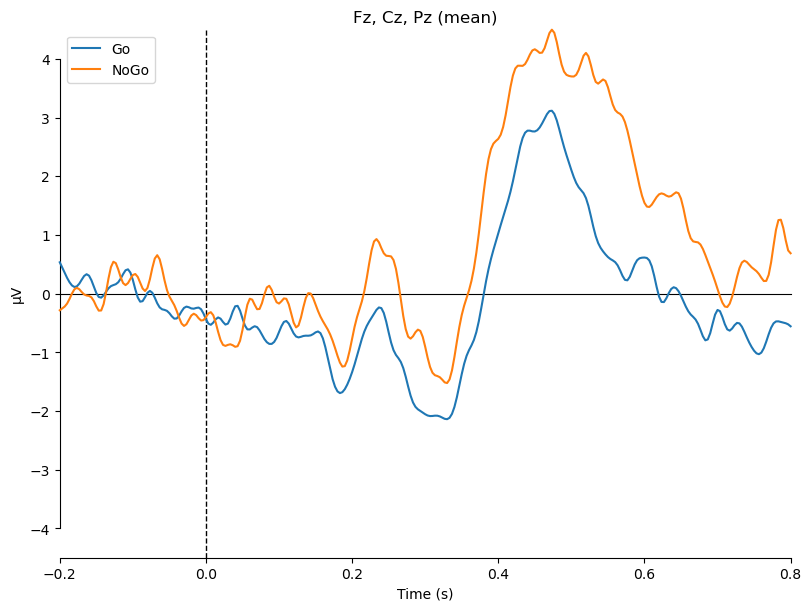

In [37]:

if 'preview_epochs' in globals():
    qc_picks = [ch for ch in QC_CHANNELS if ch in preview_epochs.ch_names]
    go_mask = preview_labels == "Go"
    nogo_mask = preview_labels == "NoGo"
    if qc_picks and go_mask.any() and nogo_mask.any():
        go_evoked = preview_epochs[go_mask].average(picks=qc_picks)
        nogo_evoked = preview_epochs[nogo_mask].average(picks=qc_picks)
        fig = mne.viz.plot_compare_evokeds(
            {"Go": go_evoked, "NoGo": nogo_evoked}, combine="mean", picks=qc_picks, show=False
        )
        display(fig)
        diff = mne.combine_evoked([nogo_evoked, go_evoked], weights=[1, -1])
    else:
        print("Pas assez d'essais Go/NoGo ou canaux manquants pour la visualisation.")
else:
    print("Exécutez d'abord le bloc précédent.")


## 3. Extraire les features ERP / TFR

Nous allons parcourir tous les fichiers trouvés, extraire les indicateurs définis plus haut et construire une grande table ().


### Bloc Type 2 — Lancer l'extraction (quelques minutes selon la machine)


In [38]:

if not ALL_EPOCH_FILES:
    ALL_EPOCH_FILES = find_epoch_files(DATA_DIR, FILE_GLOB)
    if not ALL_EPOCH_FILES:
        raise RuntimeError("Aucun fichier Go/NoGo n'est disponible.")

epoch_files = ALL_EPOCH_FILES
print(f"Extraction sur {len(epoch_files)} fichiers...")
feature_tables: List[pd.DataFrame] = []
PROCESSED_FILE_SUMMARY: List[Dict[str, object]] = []
QC_REFERENCE_EPOCHS = None
QC_REFERENCE_LABELS = None

for idx, epo_path in enumerate(epoch_files, start=1):
    if PRINT_PROGRESS:
        print(f"[{idx}/{len(epoch_files)}] {epo_path.name}")
    try:
        epochs, labels, subject_id = prepare_epochs(epo_path)
        print(f"  → {len(epochs)} epochs conservés")
    except Exception as exc:  # noqa: BLE001
        print(f"[skip] {epo_path.name}: {exc}")
        traceback.print_exc()
        continue
    try:
        subject_features = build_feature_table(epochs, labels, subject_id, epo_path)
        print(f"  → {subject_features.shape[1]} colonnes de features")
    except Exception as exc:  # noqa: BLE001
        print(f"[skip features] {epo_path.name}: {exc}")
        traceback.print_exc()
        continue
    feature_tables.append(subject_features)
    PROCESSED_FILE_SUMMARY.append(
        {
            "subject_id": subject_id,
            "file": epo_path.name,
            "n_trials": int(len(subject_features)),
            "n_go": int((subject_features["condition"] == "Go").sum()),
            "n_nogo": int((subject_features["condition"] == "NoGo").sum()),
        }
    )
    if QC_PLOTS and QC_REFERENCE_EPOCHS is None:
        QC_REFERENCE_EPOCHS = epochs.copy()
        QC_REFERENCE_LABELS = labels.copy()

if not feature_tables:
    raise RuntimeError("Aucune feature n'a pu être extraite.")

FEATURES_DF = pd.concat(feature_tables, ignore_index=True)

# Convert ERP amplitude features from Volts to microvolts (µV)
# Multiply by 1e6 for all ERP columns except latencies and TFR features
erp_amplitude_cols = [
    col for col in FEATURES_DF.columns 
    if ('mean' in col or ('peak' in col and 'value' in col)) 
    and 'latency' not in col
]
for col in erp_amplitude_cols:
    FEATURES_DF[col] = FEATURES_DF[col] * 1e6

FEATURES_DF.to_csv(FEATURES_OUT, index=False)
print(f"Features sauvegardées dans {FEATURES_OUT.resolve()}")
print(f"Taille de la table : {FEATURES_DF.shape}")
print(f"ERP amplitudes converties en µV: {erp_amplitude_cols}")
display(FEATURES_DF.head())

summary_df = pd.DataFrame(PROCESSED_FILE_SUMMARY)
if not summary_df.empty:
    display(summary_df)


Extraction sur 12 fichiers...
[1/12] sub-01_ses-001_task-gonogo_run-01_processed.fif
  → 129 epochs conservés
  → 17 colonnes de features
[2/12] sub-02_ses-001_task-gonogo_run-01_processed.fif
  → 44 epochs conservés
  → 17 colonnes de features
[3/12] sub-03_ses-001_task-gonogo_run-01_processed.fif
  → 85 epochs conservés
  → 17 colonnes de features
[4/12] sub-04_ses-001_task-gonogo_run-01_processed.fif
  → 57 epochs conservés
  → 17 colonnes de features
[5/12] sub-05_ses-001_task-gonogo_run-01_processed.fif
  → 118 epochs conservés
  → 17 colonnes de features
[6/12] sub-06_ses-001_task-gonogo_run-01_processed.fif
  → 112 epochs conservés
  → 17 colonnes de features
[7/12] sub-07_ses-001_task-gonogo_run-01_processed.fif
  → 85 epochs conservés
  → 17 colonnes de features
[8/12] sub-08_ses-001_task-gonogo_run-01_processed.fif
  → 94 epochs conservés
  → 17 colonnes de features
[9/12] sub-10_ses-001_task-gonogo_run-01_processed.fif
  → 74 epochs conservés
  → 17 colonnes de features
[10/

,subject_id,source_file,source_path,trial_index,condition,N2_mean_200_350,P3_mean_300_600_midline_fc,P3_mean_300_600_parietal,N2_peak_200_350_value,N2_peak_200_350_latency,P3_peak_300_600_value,P3_peak_300_600_latency,theta_midline_fc,mu_left,mu_right,beta_left,beta_right
0,sub-01,sub-01_ses-001_task-gonogo_run-01_processed.fif,data\gonogo\bids\derivatives\neurotheque-prepr...,0,NoGo,-17.800,-16.913,3.099,-23.926,0.350,7.308,0.553,-0.259,-0.317,-0.079,0.251,-0.503
1,sub-01,sub-01_ses-001_task-gonogo_run-01_processed.fif,data\gonogo\bids\derivatives\neurotheque-prepr...,1,Go,-12.478,-13.975,0.347,-18.046,0.323,4.489,0.440,-0.091,-0.448,-0.261,-0.194,-0.385
2,sub-01,sub-01_ses-001_task-gonogo_run-01_processed.fif,data\gonogo\bids\derivatives\neurotheque-prepr...,2,Go,-16.314,-18.118,-4.256,-21.800,0.337,1.669,0.510,0.661,-0.036,0.042,0.207,-0.604
3,sub-01,sub-01_ses-001_task-gonogo_run-01_processed.fif,data\gonogo\bids\derivatives\neurotheque-prepr...,3,Go,-21.941,-17.701,0.791,-28.002,0.340,7.542,0.393,0.089,-0.166,-0.457,-0.234,-0.435
4,sub-01,sub-01_ses-001_task-gonogo_run-01_processed.fif,data\gonogo\bids\derivatives\neurotheque-prepr...,4,Go,-15.692,-18.648,-8.239,-23.610,0.350,-1.868,0.357,-0.271,0.439,0.524,-0.090,-0.465


,subject_id,file,n_trials,n_go,n_nogo
0,sub-01,sub-01_ses-001_task-gonogo_run-01_processed.fif,129,98,31
1,sub-02,sub-02_ses-001_task-gonogo_run-01_processed.fif,44,36,8
2,sub-03,sub-03_ses-001_task-gonogo_run-01_processed.fif,85,67,18
3,sub-04,sub-04_ses-001_task-gonogo_run-01_processed.fif,57,40,17
4,sub-05,sub-05_ses-001_task-gonogo_run-01_processed.fif,118,88,30
5,sub-06,sub-06_ses-001_task-gonogo_run-01_processed.fif,112,91,21
6,sub-07,sub-07_ses-001_task-gonogo_run-01_processed.fif,85,69,16
7,sub-08,sub-08_ses-001_task-gonogo_run-01_processed.fif,94,75,19
8,sub-10,sub-10_ses-001_task-gonogo_run-01_processed.fif,74,61,13
9,sub-12,sub-12_ses-001_task-gonogo_run-01_processed.fif,154,114,40


## 4. Construire et comparer des modèles linéaires

Nous passons des features au machine learning : vecteur , labels  (0=Go, 1=NoGo) et groupes par sujet.


### Bloc Type 2 — Configurer les matrices et lancer les évaluations


In [39]:

if 'FEATURES_DF' not in globals():
    raise RuntimeError("Exécutez d'abord l'extraction des features.")

feature_df = FEATURES_DF.copy()
non_feature_cols = {"subject_id", "source_file", "source_path", "trial_index", "condition"}
numeric_cols = [
    col
    for col in feature_df.columns
    if col not in non_feature_cols and pd.api.types.is_numeric_dtype(feature_df[col])
]
if not numeric_cols:
    raise RuntimeError("Pas de colonne numérique disponible pour le ML.")

X = feature_df[numeric_cols].to_numpy(dtype=float)
valid_mask = np.isfinite(X).all(axis=1)
if not np.all(valid_mask):
    removed = int((~valid_mask).sum())
    print(f"[info] {removed} essais retirés (NaN/inf).")
    feature_df = feature_df.loc[valid_mask].reset_index(drop=True)
    X = X[valid_mask]

y = (feature_df["condition"] == "NoGo").astype(int).to_numpy()
groups = feature_df["subject_id"].to_numpy()

within_subject_results = evaluate_within_subject(X, y, groups, CLASSIFIER_CONFIG, WITHIN_SUBJECT_SPLITS)
loso_results = evaluate_loso(X, y, groups, CLASSIFIER_CONFIG)

rows = []
for name in CLASSIFIER_CONFIG.keys():
    rows.append(
        {
            "model": name,
            "within_subject_bal_acc": within_subject_results.get(name, {}).get("mean_balanced_accuracy", float("nan")),
            "loso_bal_acc": loso_results.get(name, {}).get("mean_balanced_accuracy", float("nan")),
            "loso_f1": loso_results.get(name, {}).get("mean_f1", float("nan")),
            "loso_roc_auc": loso_results.get(name, {}).get("mean_roc_auc", float("nan")),
        }
    )
display(pd.DataFrame(rows))

results_summary = {
    "n_subjects": int(np.unique(groups).size),
    "n_trials": int(len(y)),
    "feature_columns": numeric_cols,
    "within_subject": within_subject_results,
    "loso": loso_results,
}
with open(RESULTS_SUMMARY_OUT, "w", encoding="utf-8") as handle:
    json.dump(results_summary, handle, indent=2)
print(f"Résumé enregistré dans {RESULTS_SUMMARY_OUT.resolve()}")


,model,within_subject_bal_acc,loso_bal_acc,loso_f1,loso_roc_auc
0,LogisticRegression,0.615,0.604,0.400,0.649
1,LinearSVM,0.606,0.609,0.406,0.647
2,LDA,0.581,0.521,0.116,0.649


Résumé enregistré dans D:\Yann\neurotheque_resources\derivatives\results_gonogo_ml.json


### Bloc Type 3 — Test de permutation (optionnel)


In [40]:

if "X" not in globals() or "y" not in globals():
    raise RuntimeError("Lancez d'abord l'évaluation principale (matrices X/y).")
if PERMUTATION_MODEL not in CLASSIFIER_CONFIG:
    raise ValueError(f"{PERMUTATION_MODEL} n'est pas défini dans CLASSIFIER_CONFIG.")
estimator = instantiate_classifier(PERMUTATION_MODEL, CLASSIFIER_CONFIG[PERMUTATION_MODEL])
class_counts = np.bincount(y)
class_counts = class_counts[class_counts > 0]
if class_counts.size == 0:
    raise RuntimeError("Labels vides : permutation impossible.")
splits = min(WITHIN_SUBJECT_SPLITS, int(class_counts.min()))
if splits < 2:
    print("Permutation ignorée (trop peu d'essais par classe).")
else:
    cv = StratifiedKFold(n_splits=splits, shuffle=True, random_state=RANDOM_SEED)
    score, perm_scores, pvalue = permutation_test_score(
        estimator,
        X,
        y,
        cv=cv,
        n_permutations=PERMUTATION_N,
        scoring="balanced_accuracy",
        random_state=RANDOM_SEED,
    )
    print(f"Score observé : {score:.3f}")
    print(f"p-value ({PERMUTATION_N} permutations) : {pvalue:.3f}")



Score observé : 0.630
p-value (200 permutations) : 0.005
